# Figure 3 – TLS Noise in T2 Ramsey Experiments

**Device:** ibm\_algiers, qubits 5, 8, 0, 9  
**Paper:** *Sparse non-Markovian Noise Modeling of Transmon-Based Multi-Qubit Operations*, PRX Quantum (2026)  

T2 Ramsey oscillations are fit to a Two-Level System (TLS) model and compared
against a full qubit+TLS Lindblad Master Equation simulation.

**Steps:**
1. Circuit generation
2. Load experiment data and preview
3. Fit TLS model
4. Run TLS simulation
5. Paper figure

## 1  Imports and Constants

In [1]:
import numpy as np
import pickle as pk
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy as sc
import scipy.optimize as spopt
import qiskit as qk

from imports_IBM_NM import plot_colors

mpl.rc('text', usetex=True)
mpl.rc('font', family='serif')

dt = 0.035555   # identity gate duration (µs)

## 2  TLS Simulation Functions

The TLS model couples the qubit (system A) to a Two-Level System (TLS, system B).
The joint state lives in a 4-dimensional Hilbert space; after partial-tracing
over the TLS degree of freedom the qubit survival probability is recovered.

The Bloch-vector representation of the full 2-qubit density matrix uses the
15-element SU(4) basis `{XI, YI, ZI, IX, IY, IZ, XX, XY, XZ, YX, YY, YZ, ZX, ZY, ZZ}`.

In [2]:
# ── Pauli matrices ──
I1 = np.eye(2)
X  = np.array([[0, 1], [1,  0]])
Y  = np.array([[0,-1j],[1j, 0]])
Z  = np.array([[1, 0], [0, -1]])

# ── 2-qubit Pauli basis (A⊗B, qubit A = system qubit, qubit B = TLS) ──
II = np.kron(I1, I1)
XI = np.kron(X,  I1);  IX = np.kron(I1, X)
YI = np.kron(Y,  I1);  IY = np.kron(I1, Y)
ZI = np.kron(Z,  I1);  IZ = np.kron(I1, Z)
XX = np.kron(X, X);  XY = np.kron(X, Y);  XZ = np.kron(X, Z)
YX = np.kron(Y, X);  YY = np.kron(Y, Y);  YZ = np.kron(Y, Z)
ZX = np.kron(Z, X);  ZY = np.kron(Z, Y);  ZZ = np.kron(Z, Z)

basis2Q = [XI, YI, ZI, IX, IY, IZ, XX, XY, XZ, YX, YY, YZ, ZX, ZY, ZZ]

# ── Reference states ──
psi_0  = np.array([1., 0.])              # |0>
psi_00 = np.array([1., 0., 0., 0.])     # |00>
rho_00 = np.outer(psi_00, psi_00)       # |00><00|

# ── Density matrix ↔ 2-qubit Bloch vector ──
dm2bloch_2q = lambda rho: np.array([np.trace(rho @ A).real for A in basis2Q])
bloch2dm_2q = lambda v: (sum(v[n]*A for n, A in enumerate(basis2Q)) + II) / 4

# ── Partial traces ──
TrB = lambda A: np.array([[A[0,0]+A[1,1], A[0,2]+A[1,3]],
                           [A[2,0]+A[3,1], A[2,2]+A[3,3]]])  # trace out TLS

v_00 = dm2bloch_2q(rho_00)   # initial 2-qubit Bloch vector

In [3]:
def G_load(gamma, q, lmbda, beta, omega, nu, xi, k):
    """
    15x15 Lindblad generator for a qubit coupled to a TLS.

    Parameters
    ----------
    gamma : float  Qubit amplitude damping rate (MHz).
    q     : float  Ground-state thermal population.
    lmbda : float  Pure qubit dephasing rate (MHz).
    beta  : float  Qubit detuning (MHz).
    omega : float  Gate rotation rate (radians/µs).
    nu    : float  Additional gate dephasing rate (MHz).
    xi    : float  Qubit–TLS coupling strength (MHz).
    k     : float  TLS decay rate (MHz).
    """
    return np.array([
        [-gamma/2-lmbda, -beta, 0, 0, 0, 0, 0, 0, 0, -xi, 0, 0, 0, 0, 0],
        [beta, -gamma/2-lmbda-nu, -omega, 0, 0, 0, xi, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, omega, -gamma-nu, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, -k/2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, -k/2, 0, 0, 0, 0, 0, 0, 0, 0, 0, -xi],
        [0, 0, 0, 0, 0, -k, 0, 0, 0, 0, 0, 0, 0, xi, 0],
        [0, -xi, 0, 0, 0, 0, -(gamma+k)/2-lmbda, 0, 0, -beta, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, -(gamma+k)/2-lmbda, 0, 0, -beta, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, -gamma/2-lmbda-k, 0, 0, -beta, 0, 0, 0],
        [xi, 0, 0, 0, 0, 0, beta, 0, 0, -(gamma+k)/2-lmbda-nu, 0, 0, -omega, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, beta, 0, 0, -(gamma+k)/2-lmbda-nu, 0, 0, -omega, 0],
        [0, k, 0, 0, 0, 0, 0, 0, beta, 0, 0, -gamma/2-lmbda-k-nu, 0, 0, -omega],
        [0, 0, 0, gamma*(2*q-1), 0, 0, 0, 0, 0, omega, 0, 0, -gamma-k/2-nu, 0, 0],
        [0, 0, 0, 0, gamma*(2*q-1), -xi, 0, 0, 0, 0, omega, 0, 0, -gamma-k/2-nu, 0],
        [0, 0, k, 0, xi, gamma*(2*q-1), 0, 0, 0, 0, 0, omega, 0, 0, -gamma-nu-k],
    ])


def _rot_angle(name, eps):
    """Gate rotation angle in radians from gate name and amplitude error eps."""
    if name == 'id':  return 0.
    if name == 'x':   return np.pi * (1 + eps)
    if name == 'sx':  return np.pi * (1 + eps) / 2


def G_funcs(gate='id', gamma=1e-10, q=1, lmbda=0, beta=0, eps=0, nu=0, xi=0, k=1e-10):
    """Pre-compute (G, G^{-1}, exp(G*dt)) for a given gate type."""
    omega = _rot_angle(gate, eps) / dt
    b     = beta if gate == 'id' else beta / 1.5
    G     = G_load(gamma, q, lmbda, beta=b, omega=omega, nu=nu, xi=xi, k=k)
    Ginv  = sc.linalg.inv(G)
    eGt   = sc.linalg.expm(G * dt)
    return G, Ginv, eGt


def sim_exact_tls(circ, spam=0, gamma=1e-10, q=1, lmbda=0, beta=0,
                  eps=0, nu=0, xi=0, k=1e-10, backend=None, verbose=0):
    """
    Exact qubit+TLS LME simulation via 2-qubit Bloch-vector matrix exponentials.

    Parameters
    ----------
    circ   : qiskit.QuantumCircuit  Single-qubit circuit.
    spam   : float  SPAM error probability.
    gamma  : float  Qubit amplitude damping rate (MHz).
    q      : float  Ground-state thermal population.
    lmbda  : float  Pure qubit dephasing rate (MHz).
    beta   : float  Qubit detuning (MHz).
    eps    : float  Control / amplitude error.
    nu     : float  Gate dephasing rate (MHz).
    xi     : float  Qubit–TLS coupling strength (MHz).
    k      : float  TLS decay rate (MHz).

    Returns
    -------
    float  Qubit survival probability p(|0>).
    """
    t_circ = qk.compiler.transpile(
        circ, backend=backend,
        basis_gates=['id', 'x', 'rz', 'sx'],
        initial_layout=[0], optimization_level=0
    )
    c    = np.array([0, 0, gamma*(2*q-1), 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=float)
    Gs   = {}
    vt   = [v_00.copy()]

    for Cinst in t_circ:
        instr = Cinst[0]
        name  = instr.name
        if name == 'rz':
            rho    = bloch2dm_2q(vt[-1])
            rho    = ZZ @ rho @ ZZ
            new_vt = dm2bloch_2q(rho).real
        elif name in ('x', 'sx', 'id'):
            if name not in Gs:
                Gs[name] = G_funcs(gate=name, gamma=gamma, q=q, lmbda=lmbda,
                                   beta=beta, eps=eps, nu=nu, xi=xi, k=k)
            G, Ginv, eGt = Gs[name]
            new_vt = eGt @ vt[-1] + (eGt - np.eye(15)) @ Ginv @ c
        elif name in ('barrier', 'measure'):
            if verbose: print(name)
            continue
        else:
            if verbose: print(f'sim_exact_tls: unknown gate {instr}')
            return 0.
        vt.append(np.real(np.around(new_vt, 6)).tolist())

    rho_t = bloch2dm_2q(vt[-1])
    if spam:
        rho_t = (1 - spam)*rho_t + spam * XI @ rho_t @ XI
    rho_A = TrB(rho_t)
    return float((psi_0 @ rho_A @ psi_0).real)

## 3  Circuit Generation

T2 Ramsey circuits: `SX – ID×n – SX – X – Measure`.
The trailing `X` maps the |+⟩ decay endpoint to a p(|0⟩) measurement that
starts near 1 and decays towards 0.5.

In [4]:
num_points = 50                            # must match number of T2 data points
T2_max_us  = 200                           # µs

tt       = np.linspace(0, T2_max_us, num_points)          # delay axis (µs)
tt_fine  = np.linspace(tt[0], tt[-1], 1000)
num_Is   = np.linspace(0, T2_max_us / dt, num_points)     # number of identity gates

t2_circs = []
for n in num_Is:
    circ = qk.QuantumCircuit(1)
    circ.sx(0)
    for _ in range(int(n)):
        circ.id(0)
    circ.sx(0)
    circ.x(0)
    t2_circs.append(circ)

print(f'Generated {len(t2_circs)} T2 Ramsey circuits (0 – {T2_max_us} µs)')

Generated 50 T2 Ramsey circuits (0 – 200 µs)


## 4  Load Experiment Data and Preview

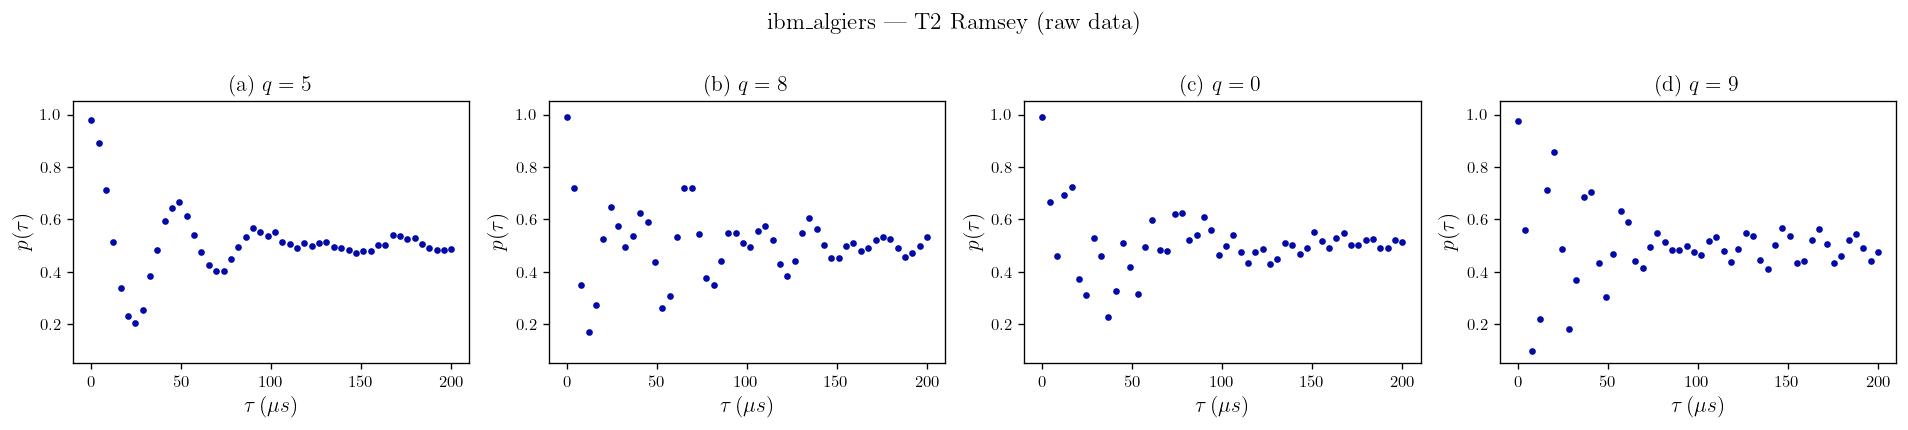

In [5]:
qubits    = [5, 8, 0, 9]
device    = 'algiers'

ps_exps_all = pk.load(open('../data/ps_exps_algiers_char.p', 'rb'))
ps_t2s      = {q: ps_exps_all[q]['t2'] for q in qubits}

labels = ['(a) $q=5$', '(b) $q=8$', '(c) $q=0$', '(d) $q=9$']

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), dpi=120)
for ax, (q, ps), lbl in zip(axes, ps_t2s.items(), labels):
    ax.plot(tt, ps, ls='', marker='o', ms=3, color=plot_colors[2])
    ax.set_xlabel(r'$\tau\,(\mu s)$', fontsize=13)
    ax.set_ylabel(r'$p(\tau)$', fontsize=13)
    ax.set_ylim(0.05, 1.05)
    ax.set_title(lbl, fontsize=13)
plt.suptitle(f'ibm_{device} — T2 Ramsey (raw data)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5  TLS Model Fit

The TLS model predicts:
$$p(\tau) = \frac{1 + e^{-a\tau}\cos(b\tau)\cos(c\tau)}{2}$$
where $a$ is the dephasing rate, $b$ the qubit detuning, and $c$ the qubit–TLS coupling.

In [6]:
TLS_fun = lambda t, a, b, c: (1 + np.exp(-a*t) * np.cos(b*t) * np.cos(c*t)) / 2

fit_params = {}
fit_errors = {}
p0_map = {5: (0.02, 0.28, 0.01), 8: (0.02, 0.28, 0.3),
          0: (0.02, 0.28, 0.3),  9: (0.02, 0.28, 0.3)}

for q, ps in ps_t2s.items():
    params, cov = spopt.curve_fit(TLS_fun, tt, ps, p0=p0_map[q])
    fit_params[q] = params
    fit_errors[q] = [np.sqrt(cov[i, i]) for i in range(3)]
    a, b, c = params
    print(f'Qubit {q:2d}:  a={a:.4f} ± {fit_errors[q][0]:.4f} MHz,  '
          f'b={b:.4f} ± {fit_errors[q][1]:.4f} MHz,  '
          f'c={c:.4f} ± {fit_errors[q][2]:.4f} MHz')

Qubit  5:  a=0.0180 ± 0.0009 MHz,  b=-0.1291 ± 0.0008 MHz,  c=-0.0128 ± 0.0008 MHz
Qubit  8:  a=0.0111 ± 0.0003 MHz,  b=0.0479 ± 0.0003 MHz,  c=0.2322 ± 0.0003 MHz
Qubit  0:  a=0.0150 ± 0.0003 MHz,  b=0.1695 ± 0.0003 MHz,  c=0.2461 ± 0.0003 MHz
Qubit  9:  a=0.0114 ± 0.0004 MHz,  b=0.0170 ± 0.0003 MHz,  c=0.3204 ± 0.0004 MHz


## 6  Qubit+TLS Simulation

The simulation uses the fitted parameters directly:
- `lmbda` ← fit parameter `a` (dephasing rate)
- `beta`  ← fit parameter `b` (qubit detuning)
- `xi`    ← fit parameter `c` (TLS coupling)

A fixed `spam=0.01` accounts for readout errors.

In [7]:
ps_sims = {}
for q, ps in ps_t2s.items():
    a, b, c = fit_params[q]
    print(f'Simulating qubit {q} ({len(t2_circs)} circuits)...', end=' ', flush=True)
    ps_sims[q] = [
        sim_exact_tls(circ, spam=0.01, lmbda=a, beta=b, xi=c)
        for circ in t2_circs
    ]
    print('done')
print('Simulation complete.')

Simulating qubit 5 (50 circuits)... done
Simulating qubit 8 (50 circuits)... done
Simulating qubit 0 (50 circuits)... done
Simulating qubit 9 (50 circuits)... done
Simulation complete.


## 7  Paper Figure (Fig. 3)

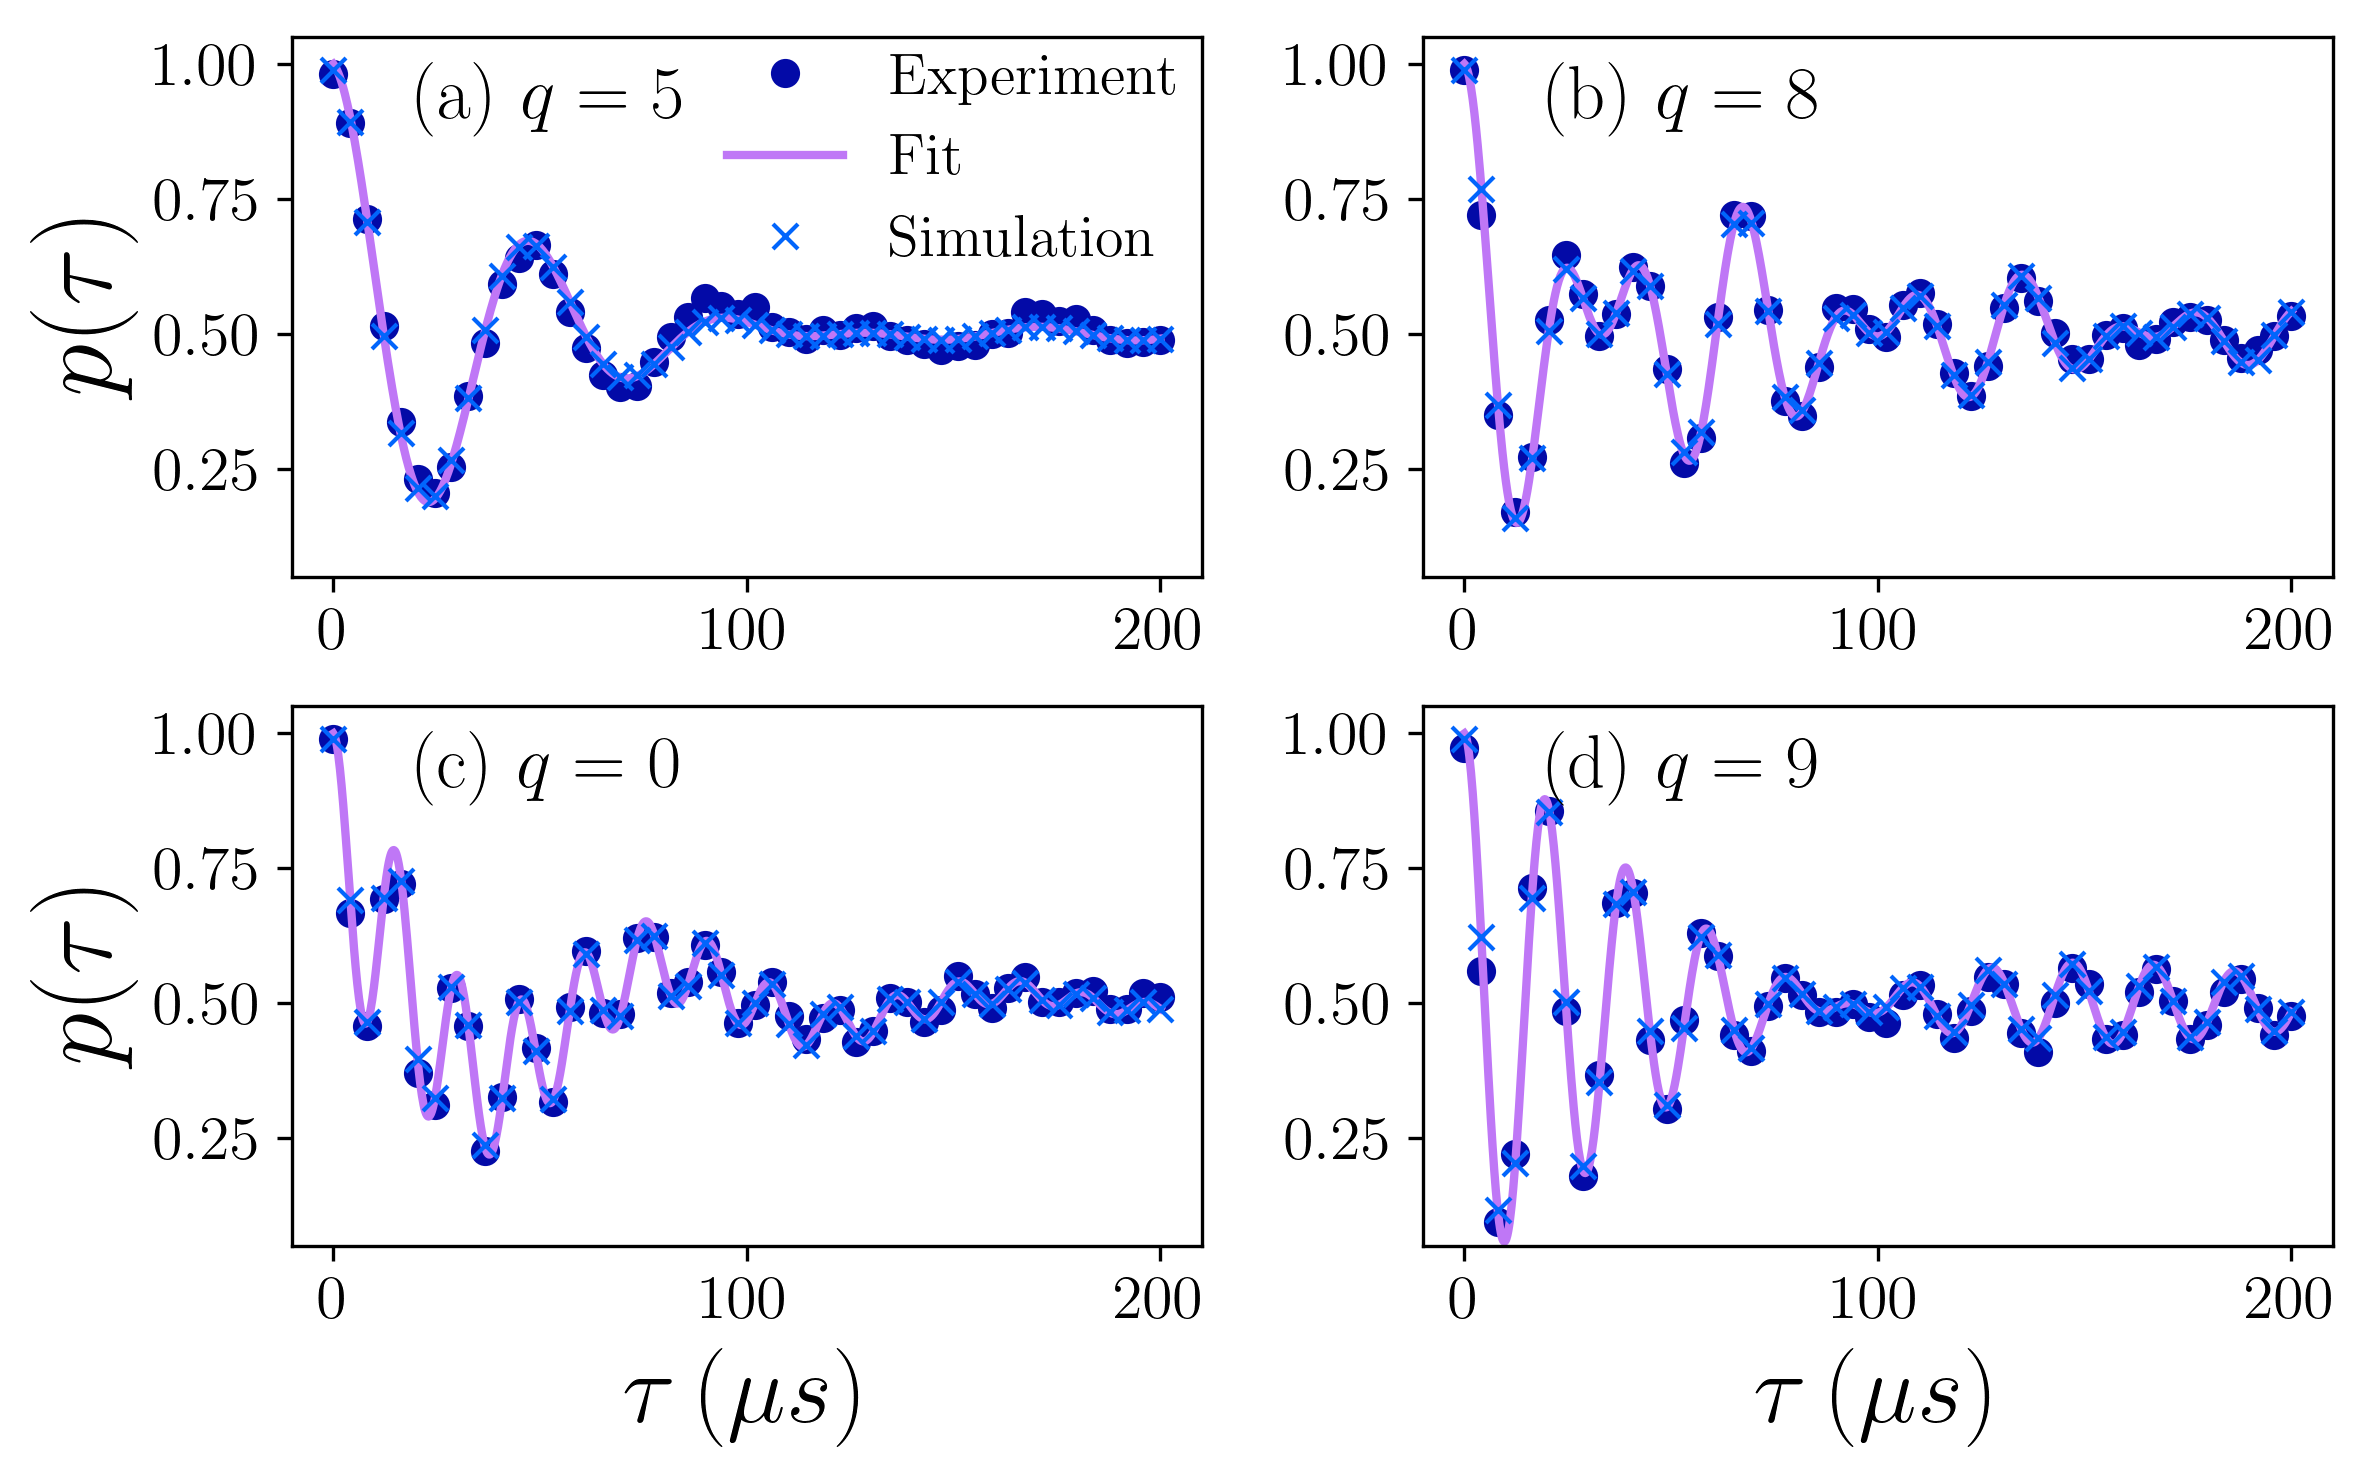

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(8, 5), dpi=300)
axes = axes.flatten()

for idx, (q, ps) in enumerate(ps_t2s.items()):
    ax = axes[idx]
    ax.plot(tt, ps,
            label='Experiment', ls='', marker='o', color=plot_colors[2])
    ax.plot(tt_fine, TLS_fun(tt_fine, *fit_params[q]),
            label='Fit', lw=2, color=plot_colors[1])
    ax.plot(tt, ps_sims[q],
            label='Simulation', lw=0, marker='x', ms=6, color=plot_colors[3])

    if idx in (0, 2): ax.set_ylabel(r'$p(\tau)$', size=26)
    if idx > 1:       ax.set_xlabel(r'$\tau\,(\mu s)$', size=24)
    ax.set_ylim(0.05, 1.05)
    ax.tick_params(axis='both', labelsize=15)
    ax.text(20, 0.9, labels[idx], fontsize=18)
    if idx == 0:
        ax.legend(frameon=False, fontsize=14, bbox_to_anchor=(0.42, 0.4755))

plt.tight_layout()
plt.savefig('../figures/fig_03_tls_ramsey.pdf', bbox_inches='tight')
plt.show()